In [19]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from PIL import Image
from IPython.display import display, Image as IPImage

project_root = os.path.abspath(".")
sys.path = [p for p in sys.path if p not in ("", ".", project_root)]
import wandb
if project_root not in sys.path:
    sys.path.insert(0, project_root)

output_dir = "thesis-writes"
os.makedirs(output_dir, exist_ok=True)

test_eval_summary_path = "out/merged/second-test/test/test_evaluation_summary.csv"
val_eval_summary_path = "out/merged/second-test/val/val_evaluation_summary.csv"
test_cd_summary_path = "out/merged/second-test/test/test_chamfer_distance_summary.csv"
val_cd_summary_path = "out/merged/second-test/val/val_chamfer_distance_summary.csv"
test_subsets_path = "out/merged/second-test/test/test_chamfer_distance_subsets_summary.csv"
val_subsets_path = "out/merged/second-test/val/val_chamfer_distance_subsets_summary.csv"

test_preds_csv_path = "out/merged-test/baseline_text2cad/test_predictions.csv"


## 1. Statistika Panjang Sekuens Global Dataset Uji

Analisis berikut mengekstraksi distribusi panjang sekuens perintah (command sequence length) pada dataset uji sebagai acuan ground truth untuk mengevaluasi kompleksitas representasi CAD.


In [20]:
df_test_preds = pd.read_csv(test_preds_csv_path)

cmd_lens = [len(json.loads(c)) for c in df_test_preds["gt_cmds_json"]]
cmd_lens_arr = np.array(cmd_lens)

seq_stats = {
    "Metrik": ["Jumlah Sampel", "Rata-rata (Mean)", "Median", "Standar Deviasi", "Minimum", "Kuartil 1 (Q1)", "Kuartil 3 (Q3)", "Maksimum", "Rentang Interkuartil (IQR)"],
    "Nilai": [
        len(cmd_lens_arr),
        round(float(np.mean(cmd_lens_arr)), 2),
        round(float(np.median(cmd_lens_arr)), 2),
        round(float(np.std(cmd_lens_arr)), 2),
        int(np.min(cmd_lens_arr)),
        round(float(np.percentile(cmd_lens_arr, 25)), 2),
        round(float(np.percentile(cmd_lens_arr, 75)), 2),
        int(np.max(cmd_lens_arr)),
        round(float(np.percentile(cmd_lens_arr, 75) - np.percentile(cmd_lens_arr, 25)), 2)
    ]
}

df_seq_stats = pd.DataFrame(seq_stats)
df_seq_stats.to_csv(os.path.join(output_dir, "tabel_panjang_sekuens_global.csv"), index=False)
display(df_seq_stats)


,Metrik,Nilai
0,Jumlah Sampel,8042.00
1,Rata-rata (Mean),16.64
2,Median,12.00
3,Standar Deviasi,12.27
4,Minimum,5.00
5,Kuartil 1 (Q1),8.00
6,Kuartil 3 (Q3),21.00
7,Maksimum,77.00
8,Rentang Interkuartil (IQR),13.00


## 2. Evaluasi Kinerja Model Individual (Baseline, M1 - M5)

Bagian ini mengevaluasi setiap arsitektur model secara individual:
- **Baseline**: Text2CAD Autoregressive monolitik.
- **M1**: DualSeq dengan Continuous Float Arguments.
- **M2**: DualSeq dengan 8-Bit Bins Tokenization.
- **M3**: DualSeq dengan Cross-Attention Fusion (Checkpoint Final).
- **M4**: DualSeq dengan Penalaan Penguatan GRPO.
- **M5**: DualSeq Variasi Lanjutan (Placeholder).

Untuk setiap model, disajikan tabel evaluasi Test & Val, representasi DualSeq contoh sampel UID `0009/00097460`, render isometrik 3D, serta kurva Kernel Density Estimation (KDE) panjang sekuens.



In [21]:
project_root = os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

df_test_eval = pd.read_csv(test_eval_summary_path)
df_val_eval = pd.read_csv(val_eval_summary_path)
df_test_cd = pd.read_csv(test_cd_summary_path)
df_val_cd = pd.read_csv(val_cd_summary_path)

# Normalisasi metrik T2C-Line-F1 dengan membagi porsi sampel yang memuat perintah LINE
porsi_line_test = df_test_eval["Line Samples"] / df_test_eval["Total Samples"] if "Line Samples" in df_test_eval.columns else (6434 / 8042)
df_test_eval["T2C-Line-F1"] = (df_test_eval["T2C-Line-F1"] / porsi_line_test).round(4)

porsi_line_val = df_val_eval["Line Samples"] / df_val_eval["Total Samples"] if "Line Samples" in df_val_eval.columns else (6983 / 8921)
df_val_eval["T2C-Line-F1"] = (df_val_eval["T2C-Line-F1"] / porsi_line_val).round(4)

df_test_merged = pd.merge(df_test_eval, df_test_cd[["Model", "Mean CD", "Median CD", "Invalid Ratio"]], on="Model", how="left")
df_val_merged = pd.merge(df_val_eval, df_val_cd[["Model", "Mean CD", "Median CD", "Invalid Ratio"]], on="Model", how="left")

target_models = [
    {"id": "Baseline", "name": "Text2CAD Monolithic Autoregressive", "folder": "baseline_text2cad"},
    {"id": "M1", "name": "DualSeq + FloatArgs", "folder": "m1"},
    {"id": "M2", "name": "DualSeq + 8-Bit Bins", "folder": "m2"},
    {"id": "M3", "name": "DualSeq + Cross-Attention Fusion (Final)", "folder": "m3"},
    {"id": "M4", "name": "DualSeq + GRPO Reinforcement", "folder": "grpo_fuse"},
    {"id": "M5", "name": "DualSeq Variasi Lanjutan (Placeholder)", "folder": None},
]

sample_uid = "0009/00097460"
sample_row = df_test_preds[df_test_preds["uid"] == sample_uid].iloc[0]
sample_prompt = sample_row["prompt"]
sample_gt_cmds = json.loads(sample_row["gt_cmds_json"])
sample_gt_args = json.loads(sample_row["gt_args_json"])

model_pred_lens = {}
sample_model_preds = {}

for m in target_models:
    mid = m["id"]
    folder = m["folder"]
    if not folder:
        continue
    csv_path = f"out/merged-test/{folder}/test_predictions.csv"
    pkl_path = f"out/merged-test/{folder}/test_predictions.pkl"
    
    if os.path.exists(csv_path):
        m_df = pd.read_csv(csv_path)
        model_pred_lens[mid] = [len(json.loads(c)) for c in m_df["pred_cmds_json"]]
        s_row = m_df[m_df["uid"] == sample_uid]
        if not s_row.empty:
            sample_model_preds[mid] = {
                "cmds": json.loads(s_row.iloc[0]["pred_cmds_json"]),
                "args": json.loads(s_row.iloc[0]["pred_args_json"]),
            }
    elif os.path.exists(pkl_path):
        with open(pkl_path, "rb") as f:
            d = pickle.load(f)
        lens = []
        for obj in d.values():
            if hasattr(obj, "cmds"):
                lens.append(len(obj.cmds))
            elif isinstance(obj, dict) and "cmds" in obj:
                lens.append(len(obj["cmds"]))
        model_pred_lens[mid] = lens
        obj = d.get(sample_uid)
        if obj is not None:
            if hasattr(obj, "cmds"):
                sample_model_preds[mid] = {"cmds": obj.cmds, "args": getattr(obj, "args_dict", [])}
            elif isinstance(obj, dict):
                sample_model_preds[mid] = {"cmds": obj.get("cmds", []), "args": obj.get("args", [])}


--- Model Baseline: Text2CAD Monolithic Autoregressive ---


,Split,CMD-F1,ARG-F1,T2C-F1,T2C-Line-F1,T2C-Arc-F1,T2C-Circle-F1,T2C-Extrude-F1,Mean CD,Invalid Ratio
0,Test,0.3371,0.1799,0.6855,0.7187,0.1498,0.3559,0.0,12.1017,0.4657
1,Val,0.3391,0.1855,0.6873,0.7158,0.1427,0.3648,0.0,11.9995,0.4664


Sampel UID: 0009/00097460
Prompt: Create a new coordinate system with Euler angles set to zero, zero, and negative ninety degrees, and a translation vector of zero, zero point one seven four four, and zero. Draw the first two-dimensional sketch on the first face, starting with the first loop. In this loop, draw a circle centered at zero point zero eight seven two, zero point zero eight seven two with a radius of zero point zero eight seven two. For the second loop, draw another circle with the same center but a smaller radius of zero point zero four one nine. On the second face, draw the first loop consisting of a line from zero point one five four two, zero point zero three one four to zero point six three eight four, zero point zero three one four, followed by an arc starting at the end of this line, with a midpoint at zero point six one zero five, zero point zero eight seven two, and ending at zero point six three eight four, zero point one four three. Continue with a line from this

,cmd,arg
step,,
1,COOR,"{""coor_euax"": 0.0, ""coor_euay"": 0.0, ""coor_eua..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.1542, ""line_sy"": 0.0314, ""line_e..."


Prediksi Baseline Commands (18 langkah): ['COOR', 'FACE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'FACE', 'LOOP', 'LINE', 'ARC', 'LINE', 'ARC', 'FACE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'EXTRUDE_NEW']


,cmd,arg
step,,
1,COOR,"{""coor_euax"": -191.25, ""coor_euay"": -192.6562,..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.0, ""circle_cy"": 0.0, ""circle_r..."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.0, ""circle_cy"": 0.0, ""circle_r..."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.0, ""line_sy"": 0.0, ""line_ex"": 0...."


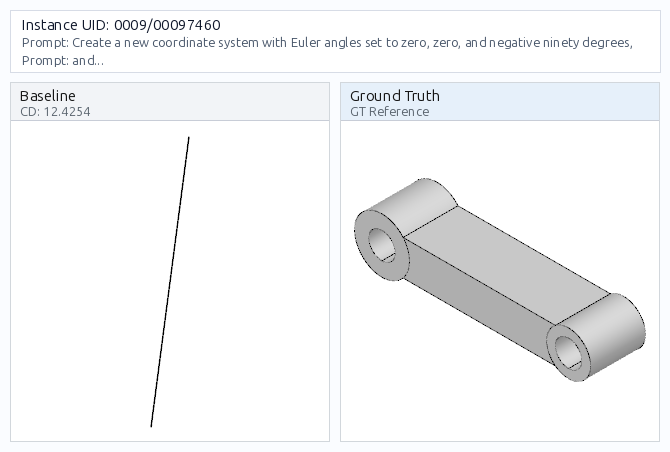

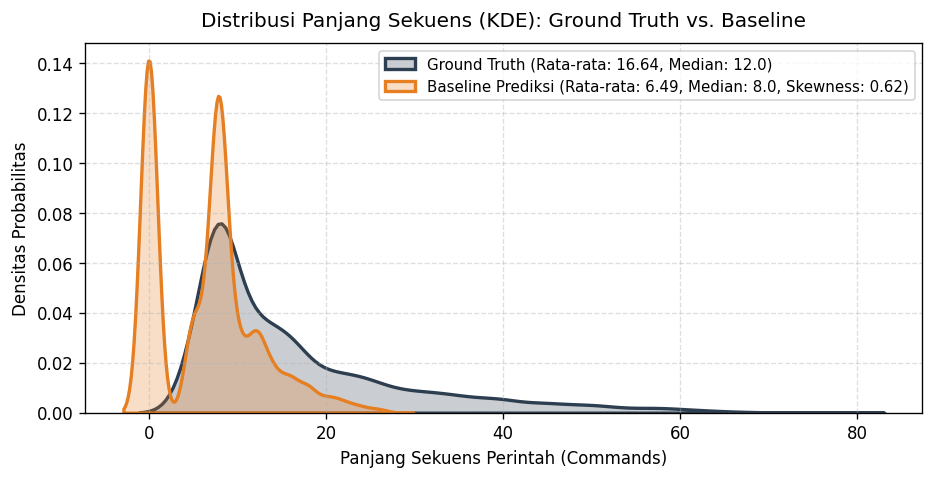


--- Model M1: DualSeq + FloatArgs ---


,Split,CMD-F1,ARG-F1,T2C-F1,T2C-Line-F1,T2C-Arc-F1,T2C-Circle-F1,T2C-Extrude-F1,Mean CD,Invalid Ratio
0,Test,0.4056,0.0937,0.7657,0.7801,0.0882,0.4496,0.8819,0.3606,0.4154
1,Val,0.4070,0.1048,0.7652,0.7765,0.0935,0.4505,0.8867,0.3459,0.4133


Sampel UID: 0009/00097460
Prompt: Create a new coordinate system with Euler angles set to zero, zero, and negative ninety degrees, and a translation vector of zero, zero point one seven four four, and zero. Draw the first two-dimensional sketch on the first face, starting with the first loop. In this loop, draw a circle centered at zero point zero eight seven two, zero point zero eight seven two with a radius of zero point zero eight seven two. For the second loop, draw another circle with the same center but a smaller radius of zero point zero four one nine. On the second face, draw the first loop consisting of a line from zero point one five four two, zero point zero three one four to zero point six three eight four, zero point zero three one four, followed by an arc starting at the end of this line, with a midpoint at zero point six one zero five, zero point zero eight seven two, and ending at zero point six three eight four, zero point one four three. Continue with a line from this

,cmd,arg
step,,
1,COOR,"{""coor_euax"": 0.0, ""coor_euay"": 0.0, ""coor_eua..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.1542, ""line_sy"": 0.0314, ""line_e..."


Prediksi M1 Commands (18 langkah): ['COOR', 'FACE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'FACE', 'LOOP', 'LINE', 'ARC', 'LINE', 'ARC', 'LINE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'EXTRUDE_NEW']


,cmd,arg
step,,
1,COOR,"{""coor_euax"": -9.25370979309082, ""coor_euay"": ..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.009381484240293503, ""circle_cy..."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.009379364550113678, ""circle_cy..."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.03575476258993149, ""line_sy"": 0...."


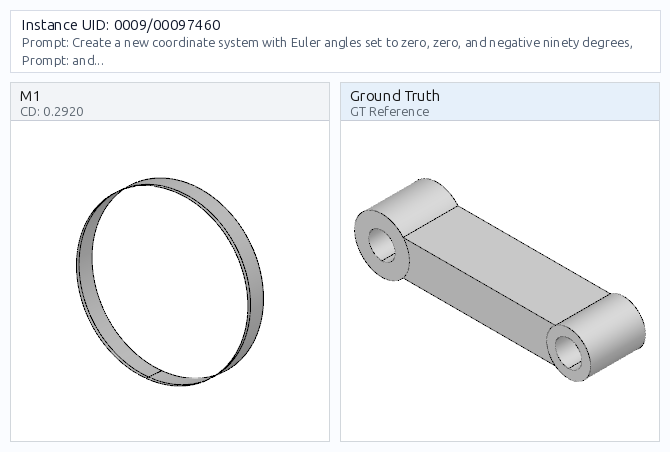

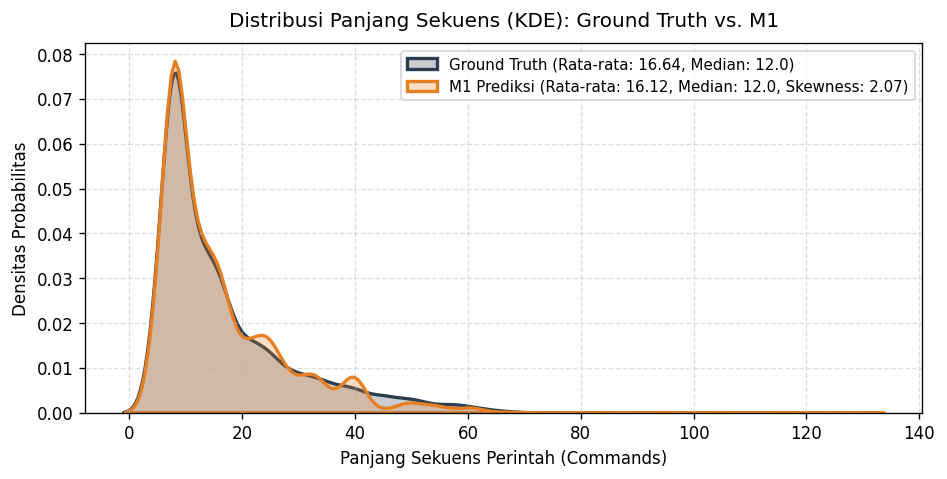


--- Model M2: DualSeq + 8-Bit Bins ---


,Split,CMD-F1,ARG-F1,T2C-F1,T2C-Line-F1,T2C-Arc-F1,T2C-Circle-F1,T2C-Extrude-F1,Mean CD,Invalid Ratio
0,Test,0.4008,0.4387,0.8070,0.8274,0.1626,0.5061,0.8921,0.1854,0.1745
1,Val,0.4014,0.4477,0.8087,0.8299,0.1680,0.5066,0.8948,2.8446,0.1713


Sampel UID: 0009/00097460
Prompt: Create a new coordinate system with Euler angles set to zero, zero, and negative ninety degrees, and a translation vector of zero, zero point one seven four four, and zero. Draw the first two-dimensional sketch on the first face, starting with the first loop. In this loop, draw a circle centered at zero point zero eight seven two, zero point zero eight seven two with a radius of zero point zero eight seven two. For the second loop, draw another circle with the same center but a smaller radius of zero point zero four one nine. On the second face, draw the first loop consisting of a line from zero point one five four two, zero point zero three one four to zero point six three eight four, zero point zero three one four, followed by an arc starting at the end of this line, with a midpoint at zero point six one zero five, zero point zero eight seven two, and ending at zero point six three eight four, zero point one four three. Continue with a line from this

,cmd,arg
step,,
1,COOR,"{""coor_euax"": 0.0, ""coor_euay"": 0.0, ""coor_eua..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.1542, ""line_sy"": 0.0314, ""line_e..."


Prediksi M2 Commands (22 langkah): ['COOR', 'FACE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'FACE', 'LOOP', 'LINE', 'ARC', 'LINE', 'ARC', 'LINE', 'ARC', 'LINE', 'ARC', 'FACE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'EXTRUDE_NEW']


,cmd,arg
step,,
1,COOR,"{""coor_euax"": 0.17578125, ""coor_euay"": 0.00390..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.0901189453125, ""circle_cy"": 0...."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.0901189453125, ""circle_cy"": 0...."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.001469140625, ""line_sy"": 0.40283..."


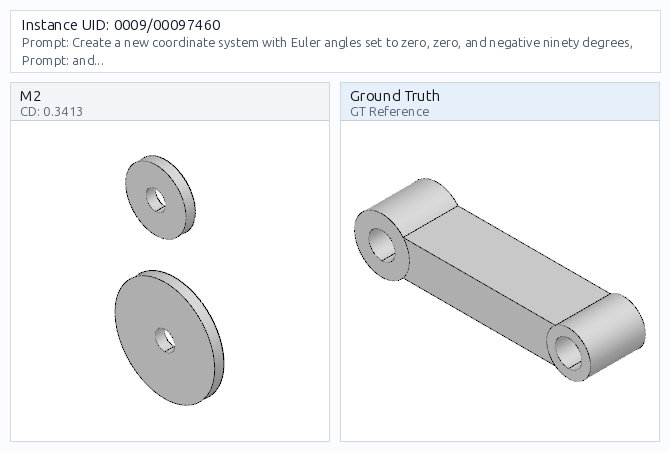

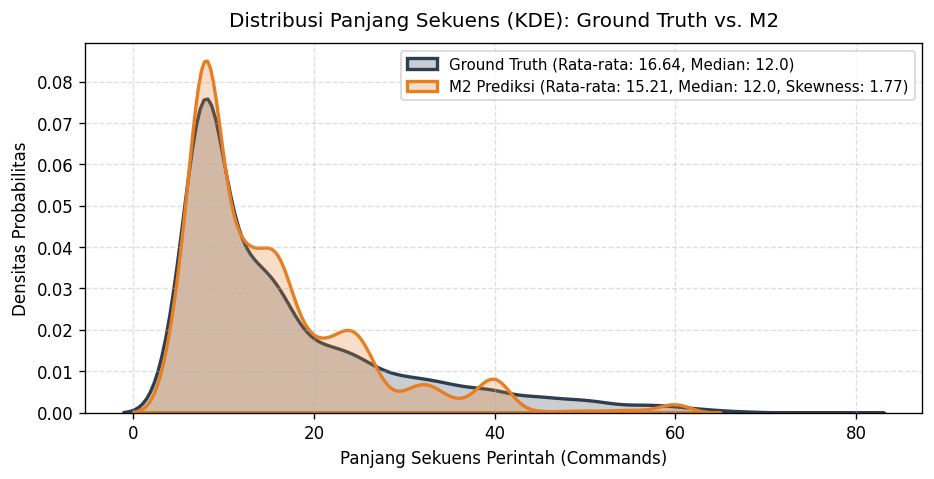


--- Model M3: DualSeq + Cross-Attention Fusion (Final) ---


,Split,CMD-F1,ARG-F1,T2C-F1,T2C-Line-F1,T2C-Arc-F1,T2C-Circle-F1,T2C-Extrude-F1,Mean CD,Invalid Ratio
0,Test,0.4398,0.6823,0.9412,0.9817,0.4549,0.5829,0.9494,96.8188,0.1089
1,Val,0.4405,0.6817,0.9413,0.9834,0.4565,0.5813,0.9516,232.6010,0.1226


Sampel UID: 0009/00097460
Prompt: Create a new coordinate system with Euler angles set to zero, zero, and negative ninety degrees, and a translation vector of zero, zero point one seven four four, and zero. Draw the first two-dimensional sketch on the first face, starting with the first loop. In this loop, draw a circle centered at zero point zero eight seven two, zero point zero eight seven two with a radius of zero point zero eight seven two. For the second loop, draw another circle with the same center but a smaller radius of zero point zero four one nine. On the second face, draw the first loop consisting of a line from zero point one five four two, zero point zero three one four to zero point six three eight four, zero point zero three one four, followed by an arc starting at the end of this line, with a midpoint at zero point six one zero five, zero point zero eight seven two, and ending at zero point six three eight four, zero point one four three. Continue with a line from this

,cmd,arg
step,,
1,COOR,"{""coor_euax"": 0.0, ""coor_euay"": 0.0, ""coor_eua..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.1542, ""line_sy"": 0.0314, ""line_e..."


Prediksi M3 Commands (18 langkah): ['COOR', 'FACE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'FACE', 'LOOP', 'LINE', 'ARC', 'LINE', 'ARC', 'FACE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'EXTRUDE_NEW']


,cmd,arg
step,,
1,COOR,"{""coor_euax"": 0.703125, ""coor_euay"": 0.0691484..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.0749794921875, ""circle_cy"": 0...."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.0749794921875, ""circle_cy"": 0...."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.1482978515625, ""line_sy"": 0.0263..."


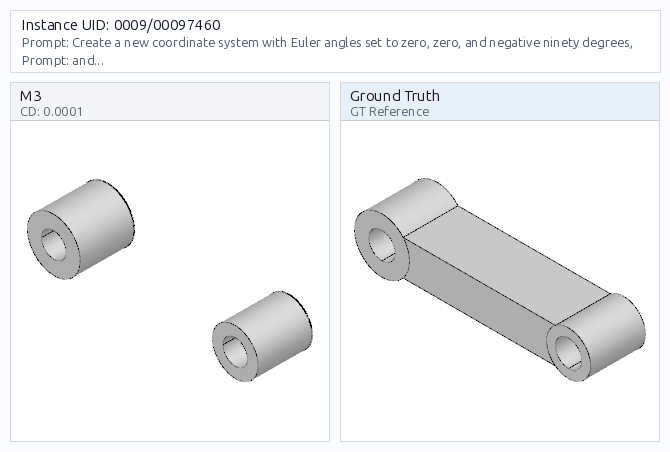

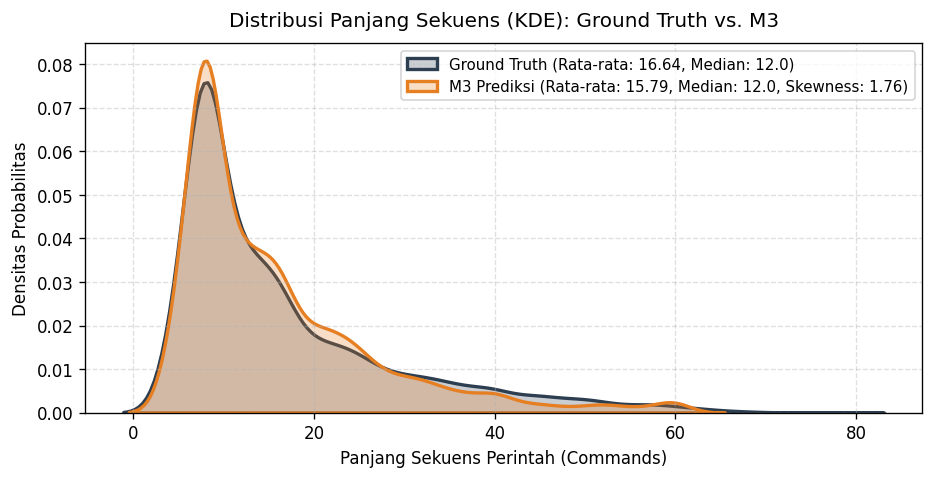


--- Model M4: DualSeq + GRPO Reinforcement ---


,Split,CMD-F1,ARG-F1,T2C-F1,T2C-Line-F1,T2C-Arc-F1,T2C-Circle-F1,T2C-Extrude-F1,Mean CD,Invalid Ratio
0,Test,0.4390,0.6818,0.9370,0.9752,0.4582,0.5813,0.9386,0.0155,0.1069
1,Val,0.4395,0.6817,0.9378,0.9783,0.4603,0.5800,0.9440,867.5123,0.1184


Sampel UID: 0009/00097460
Prompt: Create a new coordinate system with Euler angles set to zero, zero, and negative ninety degrees, and a translation vector of zero, zero point one seven four four, and zero. Draw the first two-dimensional sketch on the first face, starting with the first loop. In this loop, draw a circle centered at zero point zero eight seven two, zero point zero eight seven two with a radius of zero point zero eight seven two. For the second loop, draw another circle with the same center but a smaller radius of zero point zero four one nine. On the second face, draw the first loop consisting of a line from zero point one five four two, zero point zero three one four to zero point six three eight four, zero point zero three one four, followed by an arc starting at the end of this line, with a midpoint at zero point six one zero five, zero point zero eight seven two, and ending at zero point six three eight four, zero point one four three. Continue with a line from this

,cmd,arg
step,,
1,COOR,"{""coor_euax"": 0.0, ""coor_euay"": 0.0, ""coor_eua..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.1542, ""line_sy"": 0.0314, ""line_e..."


Prediksi M4 Commands (18 langkah): ['COOR', 'FACE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'FACE', 'LOOP', 'LINE', 'ARC', 'LINE', 'ARC', 'FACE', 'LOOP', 'CIRCLE', 'LOOP', 'CIRCLE', 'EXTRUDE_NEW']


,cmd,arg
step,,
1,COOR,"{""coor_euax"": 0.703125, ""coor_euay"": 0.0691484..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.3748974609375, ""circle_cy"": 0...."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.3748974609375, ""circle_cy"": 0...."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.0098865234375, ""line_sy"": 0.0087..."


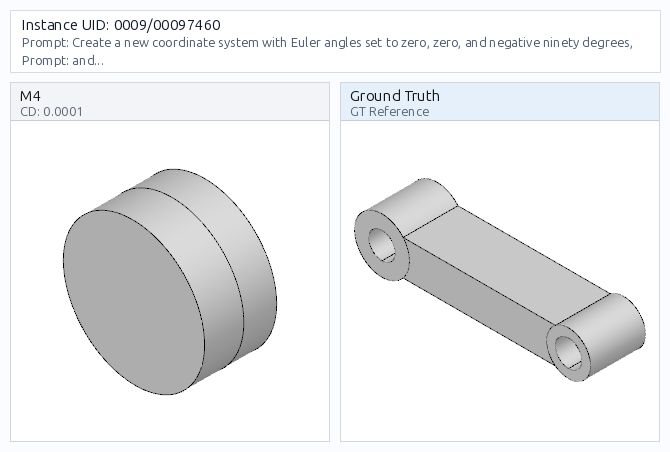

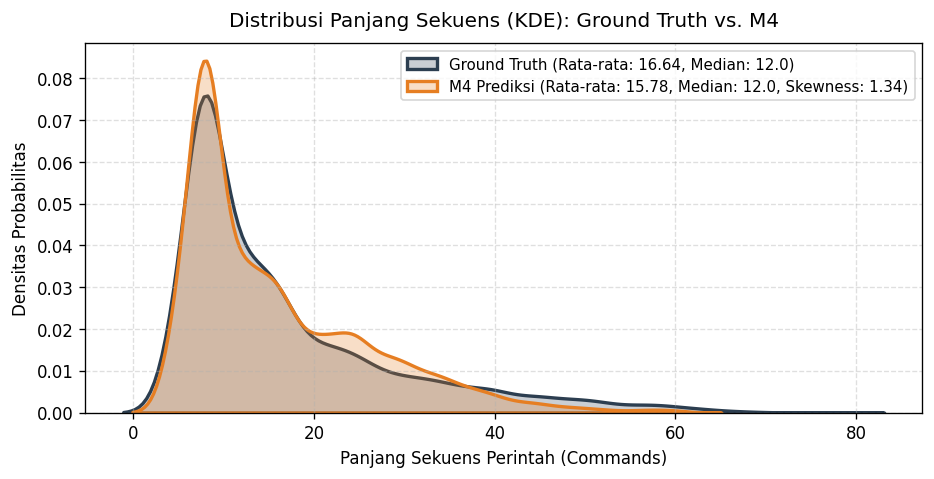


--- Model M5: DualSeq Variasi Lanjutan (Placeholder) ---
Data evaluasi belum tersedia untuk model ini (placeholder).
Sampel UID: 0009/00097460
Prompt: Create a new coordinate system with Euler angles set to zero, zero, and negative ninety degrees, and a translation vector of zero, zero point one seven four four, and zero. Draw the first two-dimensional sketch on the first face, starting with the first loop. In this loop, draw a circle centered at zero point zero eight seven two, zero point zero eight seven two with a radius of zero point zero eight seven two. For the second loop, draw another circle with the same center but a smaller radius of zero point zero four one nine. On the second face, draw the first loop consisting of a line from zero point one five four two, zero point zero three one four to zero point six three eight four, zero point zero three one four, followed by an arc starting at the end of this line, with a midpoint at zero point six one zero five, zero point zero eig

,cmd,arg
step,,
1,COOR,"{""coor_euax"": 0.0, ""coor_euay"": 0.0, ""coor_eua..."
2,FACE,-
3,LOOP,-
4,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
5,LOOP,-
6,CIRCLE,"{""circle_cx"": 0.0872, ""circle_cy"": 0.0872, ""ci..."
7,FACE,-
8,LOOP,-
9,LINE,"{""line_sx"": 0.1542, ""line_sy"": 0.0314, ""line_e..."


In [22]:
gt_lens = cmd_lens_arr
gt_mean = np.mean(gt_lens)
gt_median = np.median(gt_lens)

for m in target_models:
    mid = m["id"]
    mname = m["name"]
    print(f"--- Model {mid}: {mname} ---")
    
    # 1. Tabel Hasil Evaluasi Data Uji dan Validasi
    t_row = df_test_merged[df_test_merged["Model"] == mid]
    v_row = df_val_merged[df_val_merged["Model"] == mid]
    
    if not t_row.empty or not v_row.empty:
        summary_comp = pd.concat([
            t_row.assign(Split="Test"),
            v_row.assign(Split="Val")
        ], ignore_index=True)
        cols_to_show = ["Split", "CMD-F1", "ARG-F1",  "T2C-F1", "T2C-Line-F1", "T2C-Arc-F1", "T2C-Circle-F1", "T2C-Extrude-F1", "Mean CD", "Invalid Ratio"]
        existing_cols = [c for c in cols_to_show if c in summary_comp.columns]
        display(summary_comp[existing_cols].round(4))
    else:
        print("Data evaluasi belum tersedia untuk model ini (placeholder).")
        
    # 2. Contoh Sampel Representatif DualSeq
    print(f"Sampel UID: {sample_uid}")
    print(f"Prompt: {sample_prompt}")
    print(f"Ground Truth Commands & Arguments ({len(sample_gt_cmds)} langkah):")
    df_gt_sample = pd.DataFrame({
        "cmd": sample_gt_cmds,
        "arg": [json.dumps(a) if isinstance(a, (dict, list)) and a else ("-" if not a else str(a)) for a in sample_gt_args]
    })
    df_gt_sample.index = range(1, len(sample_gt_cmds) + 1)
    df_gt_sample.index.name = "step"
    display(df_gt_sample)
    if mid in sample_model_preds:
        p_cmds = sample_model_preds[mid]["cmds"]
        p_args = sample_model_preds[mid].get("args", [])
        print(f"Prediksi {mid} Commands ({len(p_cmds)} langkah):", p_cmds)
        if p_args and len(p_args) == len(p_cmds):
            df_pred_sample = pd.DataFrame({
                "cmd": p_cmds,
                "arg": [json.dumps(a) if isinstance(a, (dict, list)) and a else ("-" if not a else str(a)) for a in p_args]
            })
            df_pred_sample.index = range(1, len(p_cmds) + 1)
            df_pred_sample.index.name = "step"
            display(df_pred_sample)
    
    # 3. Render Isometrik 3D
    img_path = os.path.join(output_dir, f"eval_{mid}_contoh_{sample_uid.replace('/', '_')}.png")
    if os.path.exists(img_path):
        display(IPImage(filename=img_path))
    
    # 4. Kurva KDE Panjang Sekuens Model vs Ground Truth
    if mid in model_pred_lens and len(model_pred_lens[mid]) > 0:
        p_lens = np.array(model_pred_lens[mid])
        p_mean = np.mean(p_lens)
        p_median = np.median(p_lens)
        p_skew = stats.skew(p_lens)
        
        plt.figure(figsize=(9, 4), dpi=120)
        sns.kdeplot(gt_lens, label=f"Ground Truth (Rata-rata: {gt_mean:.2f}, Median: {gt_median:.1f})", color="#2C3E50", lw=2, fill=True, alpha=0.25)
        sns.kdeplot(p_lens, label=f"{mid} Prediksi (Rata-rata: {p_mean:.2f}, Median: {p_median:.1f}, Skewness: {p_skew:.2f})", color="#E67E22", lw=2, fill=True, alpha=0.25)
        plt.title(f"Distribusi Panjang Sekuens (KDE): Ground Truth vs. {mid}", fontsize=12, pad=10)
        plt.xlabel("Panjang Sekuens Perintah (Commands)", fontsize=10)
        plt.ylabel("Densitas Probabilitas", fontsize=10)
        plt.legend(frameon=True, fontsize=9)
        plt.grid(True, linestyle="--", alpha=0.4)
        kde_fig_path = os.path.join(output_dir, f"kde_panjang_sekuens_{mid}.png")
        plt.savefig(kde_fig_path, bbox_inches="tight")
        plt.show()
        plt.close()
    print()


## 3. Perbandingan Komparatif Lintas-Model

Bagian ini menyajikan sintesis komparatif menyeluruh antar-arsitektur:
1. **Tabel Evaluasi Terpadu**: Menggabungkan metrik sekuensial (CMD-F1, ARG-F1, ARG-Acc), T2C-F1 makro, F1 primitif geometris (Line, Arc, Circle, Extrude), Chamfer Distance, rasio rekonstruksi tidak valid (Invalid Ratio), dan cakupan rekonsilasi geometri (Coverage CD < 0.1).
2. **Tabel Evaluasi Berdasarkan Subset Primitif**: Evaluasi Chamfer Distance, Invalid Ratio, dan Coverage yang dibagi ke dalam himpunan subset:
   - *Line Only*: Model geometri yang hanya tersusun atas garis lurus dan ekstrusi.
   - *Line + Arc Only*: Model geometri yang memuat kurva busur (Arc).
   - *Line + Circle*: Model geometri yang memuat lingkaran penuh (Circle).
3. **Propagasi Penurunan Kerugian Pelatihan**: Kurva penurunan loss pelatihan (training loss) yang dinormalisasi pada skala langkah minimum untuk membandingkan stabilitas dan laju konvergensi.


In [23]:
# 1. Tabel Perbandingan Evaluasi Terpadu Seluruh Model (Data Uji)
df_test_merged.to_csv(os.path.join(output_dir, "tabel_perbandingan_model_keseluruhan.csv"), index=False)
display(df_test_merged)

# 2. Tabel Perbandingan Evaluasi Subset Primitif Geometri (Data Uji)
df_test_subsets = pd.read_csv(test_subsets_path)
df_test_subsets.to_csv(os.path.join(output_dir, "tabel_perbandingan_model_subset.csv"), index=False)
display(df_test_subsets)


,Model,CMD-F1,ARG-F1,ARG-Acc,T2C-F1,T2C-Line-F1,T2C-Arc-F1,T2C-Circle-F1,T2C-Extrude-F1,Mean-Arc-Token-Error,Median-Arc-Token-Error,Mean-ARG-Token-Error,Median-ARG-Token-Error,Total Samples,Line Samples,Arc Samples,Circle Samples,Mean CD,Median CD,Invalid Ratio
0,Baseline,0.3371,0.1799,0.1700,0.6855,0.7187,0.1498,0.3559,0.0000,19.38,13.0,25.10,13.0,8042,6434,1579,3307,12.10174,12.32737,0.4657
1,M1,0.4056,0.0937,0.0942,0.7657,0.7801,0.0882,0.4496,0.8819,17.84,11.0,11.42,4.0,8042,6434,1579,3307,0.36059,0.34625,0.4154
2,M2,0.4008,0.4387,0.4378,0.8070,0.8274,0.1626,0.5061,0.8921,13.92,9.0,7.61,0.0,8042,6434,1579,3307,0.18545,0.11195,0.1745
3,M3,0.4398,0.6823,0.6780,0.9412,0.9817,0.4549,0.5829,0.9494,1.60,0.0,1.13,0.0,8042,6434,1579,3307,96.81877,0.00149,0.1089
4,M4,0.4390,0.6818,0.6852,0.9370,0.9752,0.4582,0.5813,0.9386,1.34,0.0,1.08,0.0,8042,6434,1579,3307,0.01554,0.00148,0.1069


,Model,Subset,Total Samples,Valid Count,Mean CD,Median CD,Invalid Ratio
0,Baseline,Line Only,3990,2298,11.85127,12.18752,0.4241
1,Baseline,Line + Arc Only,728,236,12.08253,12.28380,0.6758
2,Baseline,Line + Circle,954,554,12.25379,12.35953,0.4193
3,M1,Line Only,3990,2123,0.37609,0.36221,0.4679
4,M1,Line + Arc Only,728,338,0.30964,0.28107,0.5357
5,M1,Line + Circle,954,727,0.31029,0.30085,0.2379
6,M2,Line Only,3990,3467,0.20486,0.12839,0.1311
7,M2,Line + Arc Only,728,262,0.29559,0.15270,0.6401
8,M2,Line + Circle,954,890,0.20059,0.12159,0.0671
9,M3,Line Only,3990,3925,0.01250,0.00123,0.0163


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/alief/.netrc


Mengunduh data WandB untuk Baseline (14421037-institut-teknologi-bandung/PRJKCAD/vedvuq93)...
  Baseline: Berhasil mengunduh 2000 titik data (step maksimum: 44339)
Mengunduh data WandB untuk M1 (14421037-institut-teknologi-bandung/PRJKCAD/pbhz10u4)...
  M1: Berhasil mengunduh 2000 titik data (step maksimum: 258564)
Mengunduh data WandB untuk M2 (14421037-institut-teknologi-bandung/PRJKCAD/tafxzwzd)...
  M2: Berhasil mengunduh 2000 titik data (step maksimum: 71740)
Mengunduh data WandB untuk M3 (14421037-institut-teknologi-bandung/PRJKCAD/m7jyac5c)...
  M3: Berhasil mengunduh 2000 titik data (step maksimum: 100648)
M4: Status placeholder (pelatihan tidak tercatat di WandB)
M5: Status placeholder (pelatihan tidak tercatat di WandB)
Batas normalisasi langkah bersama (least common steps): 44339 langkah
Grafik kurva propagasi loss berhasil disimpan ke: thesis-writes/kurva_propagasi_loss_pelatihan.png


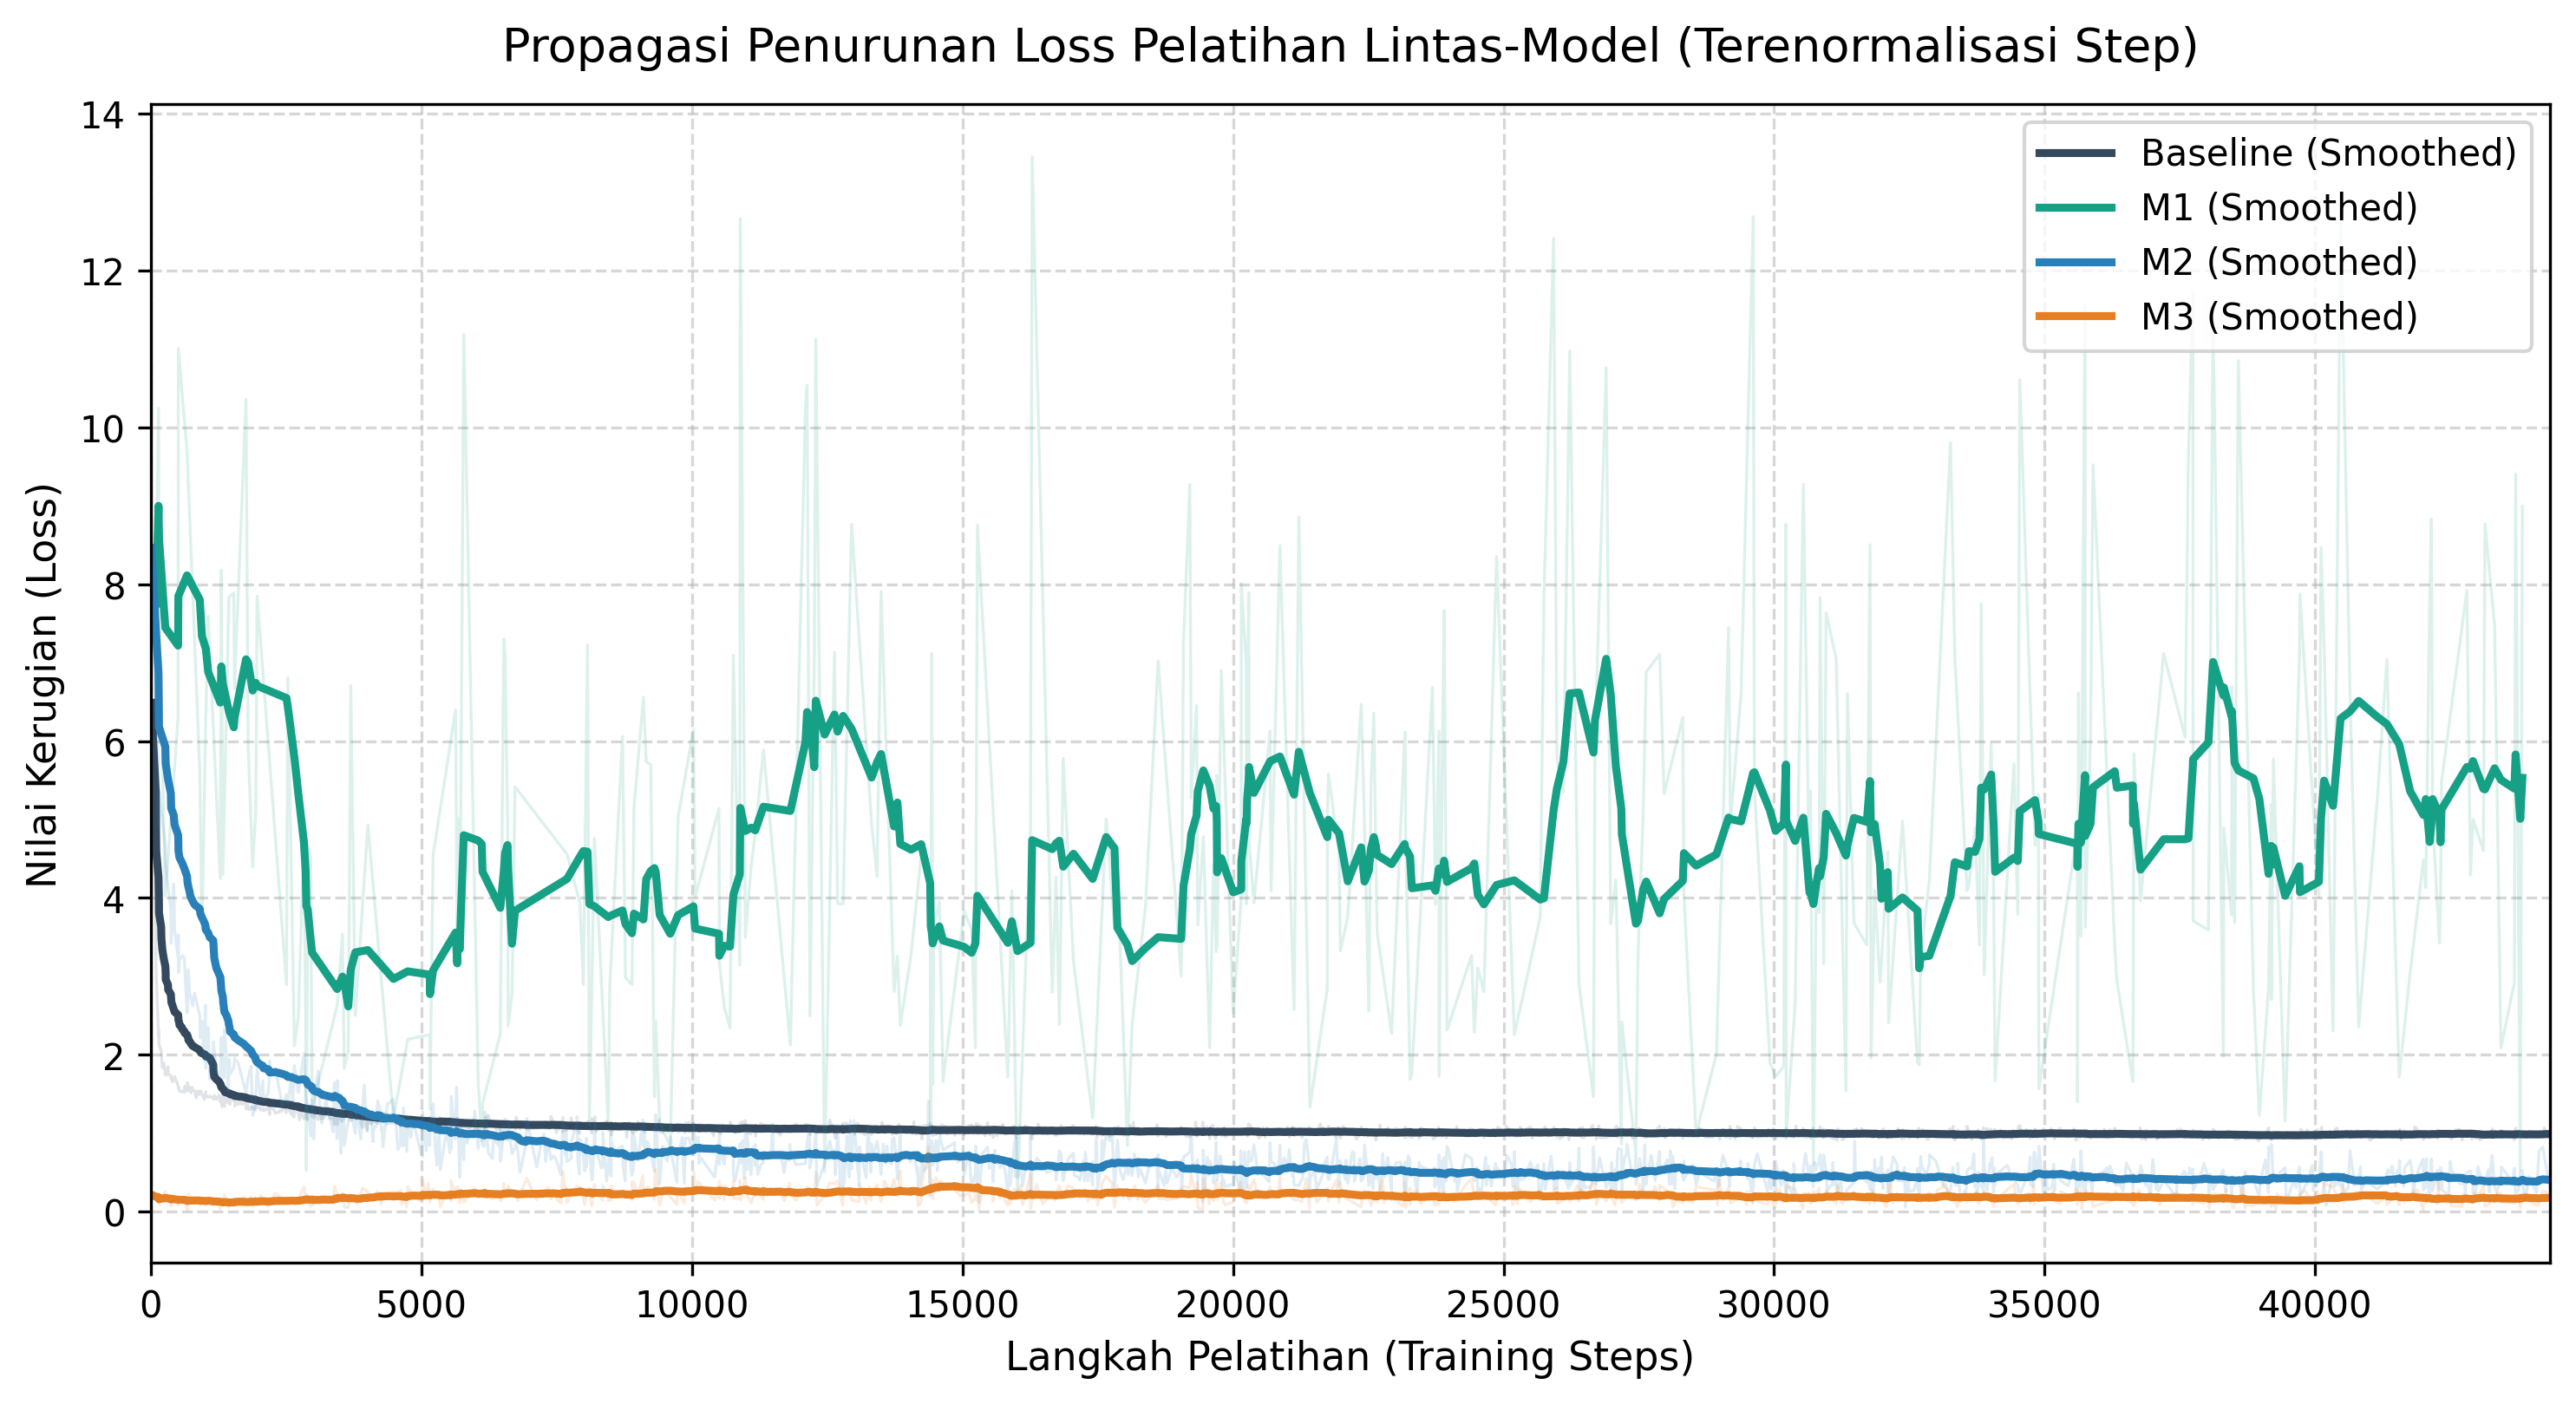

In [24]:
# Inisialisasi API WandB langsung dari kredensial environment
wandb_api_key = os.environ.get("WANDB_API_KEY")
if wandb_api_key:
    wandb.login(key=wandb_api_key)

api = wandb.Api()
entity = getattr(api.viewer, "entity", None) or os.environ.get("WANDB_ENTITY", "14421037-institut-teknologi-bandung")
project = os.environ.get("WANDB_PROJECT", "PRJKCAD")

# Konfigurasi run Weights & Biases untuk setiap model
WANDB_RUNS = [
    {"id": "Baseline", "path": f"{entity}/{project}/vedvuq93", "metric": "train/loss_step", "color": "#34495E"},
    {"id": "M1", "path": f"{entity}/{project}/pbhz10u4", "metric": "train/loss_step", "color": "#16A085"},
    {"id": "M2", "path": f"{entity}/{project}/tafxzwzd", "metric": "train/loss_step", "color": "#2980B9"},
    {"id": "M3", "path": f"{entity}/{project}/m7jyac5c", "metric": "train_loss_step", "color": "#E67E22"},
    {"id": "M4", "path": None, "metric": None, "color": "#9B59B6"},
    {"id": "M5", "path": None, "metric": None, "color": "#95A5A6"},
]

history_data = {}
for item in WANDB_RUNS:
    mid = item["id"]
    r_path = item["path"]
    m_key = item["metric"]
    
    if not r_path:
        print(f"{mid}: Status placeholder (pelatihan tidak tercatat di WandB)")
        continue
        
    print(f"Mengunduh data WandB untuk {mid} ({r_path})...")
    run = api.run(r_path)
    hist = run.history(keys=[m_key, "_step"], samples=2000, pandas=True)
    
    if not hist.empty and m_key in hist.columns and "_step" in hist.columns:
        valid_df = hist[["_step", m_key]].dropna().rename(columns={"_step": "step", m_key: "loss"}).copy()
        valid_df = valid_df.sort_values("step").drop_duplicates("step")
        valid_df = valid_df[np.isfinite(valid_df["loss"]) & (valid_df["loss"] > 0)]
        history_data[mid] = valid_df
        print(f"  {mid}: Berhasil mengunduh {len(valid_df)} titik data (step maksimum: {int(valid_df['step'].max())})")
    else:
        print(f"  {mid}: Metrik {m_key} tidak ditemukan pada run {r_path}")

# Normalisasi grafik berdasarkan jumlah langkah minimum bersama
if history_data:
    min_common_steps = min(int(df["step"].max()) for df in history_data.values())
    print(f"Batas normalisasi langkah bersama (least common steps): {min_common_steps} langkah")
    
    fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)
    for item in WANDB_RUNS:
        mid = item["id"]
        color = item["color"]
        if mid in history_data:
            df_m = history_data[mid]
            sub_df = df_m[df_m["step"] <= min_common_steps].copy()
            window_size = max(len(sub_df) // 35, 5)
            smoothed = sub_df["loss"].rolling(window=window_size, min_periods=1).mean()
            ax.plot(sub_df["step"], smoothed, label=f"{mid} (Smoothed)", color=color, linewidth=2.2)
            ax.plot(sub_df["step"], sub_df["loss"], color=color, alpha=0.15, linewidth=0.8)
            
    ax.set_title("Propagasi Penurunan Loss Pelatihan Lintas-Model (Terenormalisasi Step)", fontsize=13, pad=12)
    ax.set_xlabel("Langkah Pelatihan (Training Steps)", fontsize=11)
    ax.set_ylabel("Nilai Kerugian (Loss)", fontsize=11)
    ax.set_xlim(0, min_common_steps)
    ax.legend(frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=10, loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    
    loss_img_path = os.path.join(output_dir, "kurva_propagasi_loss_pelatihan.png")
    fig.savefig(loss_img_path, dpi=300, bbox_inches="tight")
    print(f"Grafik kurva propagasi loss berhasil disimpan ke: {loss_img_path}")
    plt.show()
    plt.close(fig)
